# Project 4 — Model Evaluation, Cross-Validation, and Hyperparameter Reasoning

This notebook focuses on fair model comparison, cross-validation, leakage prevention, learning curves, validation curves, and analytical hyperparameter reasoning without relying mainly on brute-force search.

## Theoretical background: evaluation design and hyperparameter reasoning

A model evaluation protocol should estimate how a model will behave on data it has not seen. The central danger is **data leakage**, where information from validation or test data influences training. Leakage can happen through preprocessing, feature selection, resampling, or repeated tuning on the test set.

A single train/test split can be unstable because the result depends on which samples fall into each partition. **k-fold cross-validation** reduces this dependence by evaluating the model across several train/validation splits. **Stratified k-fold** preserves class proportions in each fold, which is especially important in classification. **Repeated cross-validation** repeats the splitting process to estimate variability more reliably.

Hyperparameters should not be treated as magic values found only by brute force. **Learning curves** show whether the model needs more data or has too much bias. **Validation curves** show how a specific hyperparameter changes training and validation performance. A good hyperparameter region is often a stable region with good validation performance, not necessarily the single highest point.

Pipelines are important because preprocessing must be fitted only on the training fold inside each cross-validation split. This notebook emphasizes manual reasoning from curves before using automated search as a reference.

## Problem statement

Given multiple candidate models and hyperparameter settings, evaluate them fairly and select a model without leaking test information.

## Dataset description and source

The Breast Cancer Wisconsin dataset is loaded directly from `sklearn.datasets.load_breast_cancer`. It is binary, fast to evaluate repeatedly, and suitable for demonstrating cross-validation behavior.

The notebook begins by importing the scientific Python stack, setting a reproducible random seed, and configuring plots. Keeping these imports together makes the workflow easier to rerun and debug.

In [1]:
# Optional: run this only if your environment is missing packages.
# !pip install numpy pandas matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier

The Breast Cancer dataset is loaded directly from scikit-learn. The initial checks show the number of observations, feature columns, target labels, and whether the task is suitable for classification experiments.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
X = df.drop(columns="target")
y = df["target"]
print("Shape:", df.shape)
print("Class distribution:")
display(y.value_counts(normalize=True).rename("proportion").to_frame())
display(df.head())

Shape: (569, 31)
Class distribution:


,proportion
1,0.627417
0,0.372583


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Analytical interpretation

The dataset is clean and compact, which makes it suitable for repeated experiments. The class proportions should be checked before interpreting accuracy because imbalance can make a naive classifier look better than it really is.

## Concise EDA summary

The correlation heatmap summarizes linear associations among features and the target. Strong feature-feature correlations are especially relevant for coefficient interpretation and regularized linear models.

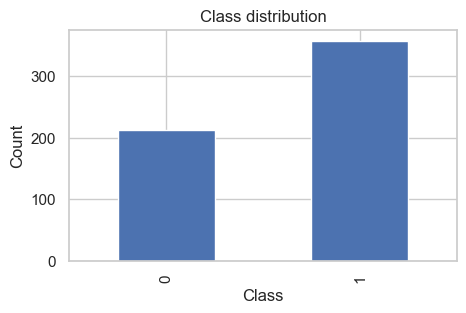

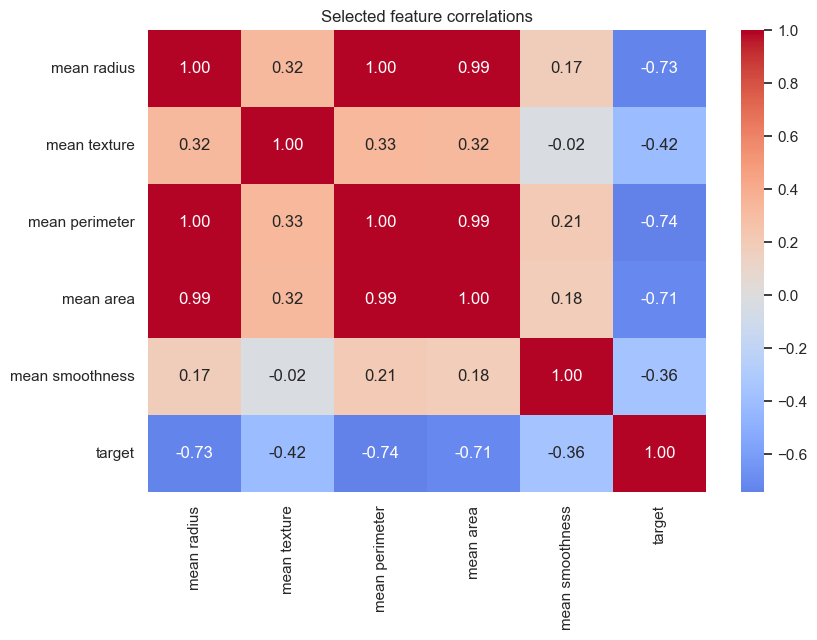

In [3]:
fig, ax = plt.subplots(figsize=(5,3))
y.value_counts().sort_index().plot(kind="bar", ax=ax, title="Class distribution")
ax.set_xlabel("Class"); ax.set_ylabel("Count"); plt.show()

selected = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness"]
plt.figure(figsize=(9,6))
sns.heatmap(df[selected + ["target"]].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Selected feature correlations")
plt.show()

### Analytical interpretation

The heatmap helps identify redundant predictors and strong linear associations. When predictors are correlated, coefficient-based interpretation becomes less direct because multiple variables may share the same explanatory signal.

## Hold out final test set

The test set is kept untouched during model selection. All comparison and hyperparameter reasoning below uses only the training portion.

The data are split into separate partitions so that model selection and final evaluation remain distinct. This separation prevents the test set from influencing hyperparameter choices.

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(X_train_full.shape, X_test.shape)

(455, 30) (114, 30)


### Analytical interpretation

The split sizes confirm that training, validation, and testing are separated. The validation set supports model selection, while the final test set should be used only after the modeling decisions are fixed.

## Demonstration: unstable single split

The same model can produce different scores under different random splits. This motivates cross-validation.

The data are split into separate partitions so that model selection and final evaluation remain distinct. This separation prevents the test set from influencing hyperparameter choices.

,seed,accuracy,F1
count,20.00000,20.000000,20.000000
mean,9.50000,0.982456,0.985989
std,5.91608,0.013649,0.010909
min,0.00000,0.956140,0.964539
25%,4.75000,0.973684,0.979021
50%,9.50000,0.982456,0.986111
75%,14.25000,0.991228,0.993007
max,19.00000,1.000000,1.000000


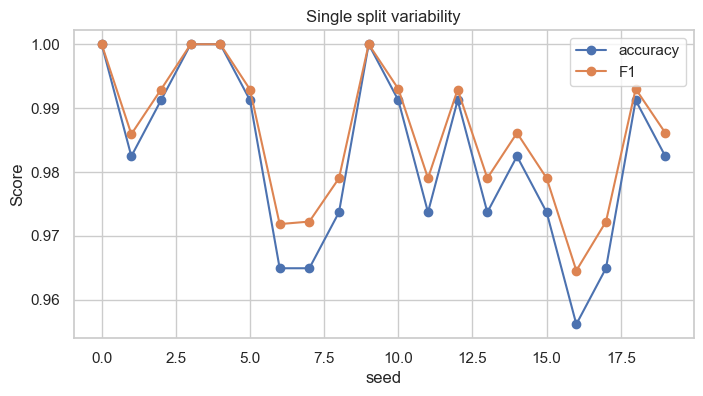

In [5]:
split_rows = []
for seed in range(20):
    X_tr, X_va, y_tr, y_va = train_test_split(X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=seed)
    model = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000))])
    model.fit(X_tr, y_tr)
    pred = model.predict(X_va)
    split_rows.append({"seed": seed, "accuracy": accuracy_score(y_va, pred), "F1": f1_score(y_va, pred)})
split_df = pd.DataFrame(split_rows)
display(split_df.describe())
split_df.plot(x="seed", y=["accuracy", "F1"], marker="o", figsize=(8,4), title="Single split variability")
plt.ylabel("Score")
plt.show()

### Analytical interpretation

The split sizes confirm that training, validation, and testing are separated. The validation set supports model selection, while the final test set should be used only after the modeling decisions are fixed.

## k-fold cross-validation: 3, 5, and 10 folds

Cross-validation is used to estimate performance across multiple splits. The mean score describes central tendency, while the standard deviation indicates how sensitive the estimate is to the particular split.

In [6]:
base_model = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000))])
cv_rows = []
for k in [3, 5, 10]:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    start=time.time()
    scores = cross_val_score(base_model, X_train_full, y_train_full, cv=cv, scoring="f1")
    runtime=time.time()-start
    cv_rows.append({"folds": k, "mean_F1": scores.mean(), "std_F1": scores.std(), "runtime_sec": runtime})
display(pd.DataFrame(cv_rows))

,folds,mean_F1,std_F1,runtime_sec
0,3,0.980819,0.002346,0.033445
1,5,0.982544,0.007752,0.083206
2,10,0.985948,0.010874,0.210453


### Analytical interpretation

Cross-validation results should be read as a distribution, not a single number. A high mean with high standard deviation is less reliable than a slightly lower mean with consistently small variation across folds.

## Why stratification matters

Cross-validation is used to estimate performance across multiple splits. The mean score describes central tendency, while the standard deviation indicates how sensitive the estimate is to the particular split.

In [7]:
def fold_class_distribution(cv, X, y):
    rows=[]
    for fold, (_, val_idx) in enumerate(cv.split(X, y), start=1):
        counts = y.iloc[val_idx].value_counts(normalize=True).sort_index()
        rows.append({"fold": fold, **{f"class_{c}_prop": counts.get(c, 0) for c in sorted(y.unique())}})
    return pd.DataFrame(rows)

print("Non-stratified KFold:")
display(fold_class_distribution(KFold(n_splits=5, shuffle=True, random_state=1), X_train_full, y_train_full))
print("StratifiedKFold:")
display(fold_class_distribution(StratifiedKFold(n_splits=5, shuffle=True, random_state=1), X_train_full, y_train_full))

Non-stratified KFold:


,fold,class_0_prop,class_1_prop
0,1,0.373626,0.626374
1,2,0.384615,0.615385
2,3,0.461538,0.538462
3,4,0.329670,0.670330
4,5,0.318681,0.681319


StratifiedKFold:


,fold,class_0_prop,class_1_prop
0,1,0.373626,0.626374
1,2,0.373626,0.626374
2,3,0.373626,0.626374
3,4,0.373626,0.626374
4,5,0.373626,0.626374


### Analytical interpretation

Cross-validation results should be read as a distribution, not a single number. A high mean with high standard deviation is less reliable than a slightly lower mean with consistently small variation across folds.

## Repeated cross-validation

Cross-validation is used to estimate performance across multiple splits. The mean score describes central tendency, while the standard deviation indicates how sensitive the estimate is to the particular split.

Number of scores: 25
Mean F1: 0.9804850990381031
Std F1: 0.009293936970805293


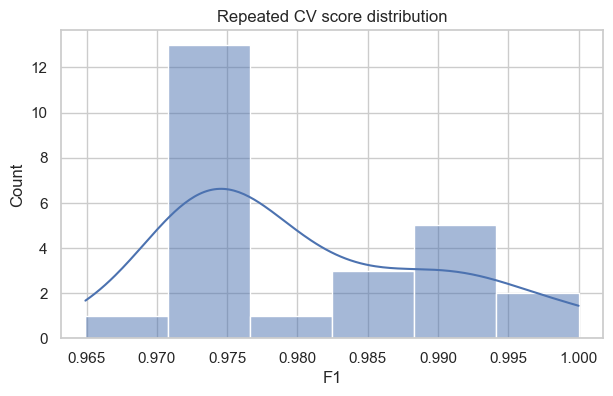

In [8]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
scores = cross_val_score(base_model, X_train_full, y_train_full, cv=rskf, scoring="f1")
print("Number of scores:", len(scores))
print("Mean F1:", scores.mean())
print("Std F1:", scores.std())
plt.figure(figsize=(7,4))
sns.histplot(scores, kde=True)
plt.title("Repeated CV score distribution")
plt.xlabel("F1")
plt.show()

### Analytical interpretation

Cross-validation results should be read as a distribution, not a single number. A high mean with high standard deviation is less reliable than a slightly lower mean with consistently small variation across folds.

## Pipeline and data leakage

Preprocessing must be learned only from training folds inside cross-validation. Scaling before CV leaks information from validation folds. The correct approach is to put scaling inside a `Pipeline`.

Cross-validation is used to estimate performance across multiple splits. The mean score describes central tendency, while the standard deviation indicates how sensitive the estimate is to the particular split.

In [9]:
# Wrong pattern: scaling is fitted on all training data before CV. This can leak validation-fold information.
scaler = StandardScaler()
X_scaled_wrong = scaler.fit_transform(X_train_full)
wrong_scores = cross_val_score(LogisticRegression(max_iter=5000), X_scaled_wrong, y_train_full, cv=5, scoring="f1")

# Correct pattern: scaling is fitted inside each fold.
correct_scores = cross_val_score(base_model, X_train_full, y_train_full, cv=5, scoring="f1")
print("Wrong pre-scaled CV mean:", wrong_scores.mean())
print("Correct pipeline CV mean:", correct_scores.mean())
print("The gap may be small here, but the wrong pattern is still conceptually unsafe.")

Wrong pre-scaled CV mean: 0.9843438445612358
Correct pipeline CV mean: 0.9843438445612358
The gap may be small here, but the wrong pattern is still conceptually unsafe.


### Analytical interpretation

Cross-validation results should be read as a distribution, not a single number. A high mean with high standard deviation is less reliable than a slightly lower mean with consistently small variation across folds.

## Learning curves

Learning curves help diagnose whether more data may help and whether the model is high-bias or high-variance.

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

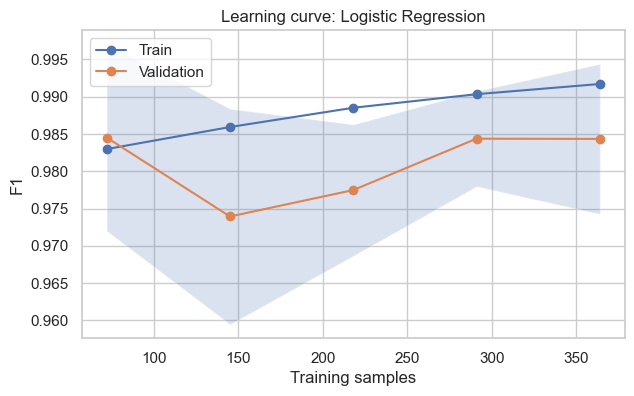

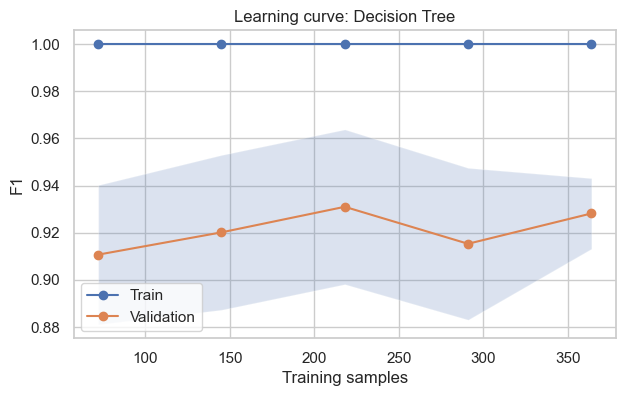

In [10]:
models_for_lc = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000))]),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE)
}
for name, model in models_for_lc.items():
    sizes, train_scores, val_scores = learning_curve(model, X_train_full, y_train_full, cv=5, scoring="f1", train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1)
    plt.figure(figsize=(7,4))
    plt.plot(sizes, train_scores.mean(axis=1), marker="o", label="Train")
    plt.plot(sizes, val_scores.mean(axis=1), marker="o", label="Validation")
    plt.fill_between(sizes, val_scores.mean(axis=1)-val_scores.std(axis=1), val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.2)
    plt.title(f"Learning curve: {name}")
    plt.xlabel("Training samples")
    plt.ylabel("F1")
    plt.legend(); plt.show()

### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Validation curves: analytical hyperparameter studies

The goal is to understand behavior, not blindly search. Each curve compares training and validation scores.

Validation curves isolate the effect of one hyperparameter at a time. The train-validation gap is often more informative than the best validation score alone.

In [11]:
def plot_validation_curve(model, param_name, param_range, X, y, scoring="f1", logx=False, title=None):
    train_scores, val_scores = validation_curve(model, X, y, param_name=param_name, param_range=param_range, cv=5, scoring=scoring, n_jobs=-1)
    train_mean, val_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)
    train_std, val_std = train_scores.std(axis=1), val_scores.std(axis=1)
    plt.figure(figsize=(7,4))
    x = np.arange(len(param_range)) if any(v is None for v in param_range) else param_range
    plt.plot(x, train_mean, marker="o", label="Train")
    plt.plot(x, val_mean, marker="o", label="Validation")
    plt.fill_between(x, val_mean-val_std, val_mean+val_std, alpha=0.2)
    if any(v is None for v in param_range):
        plt.xticks(x, [str(v) for v in param_range])
    if logx and not any(v is None for v in param_range):
        plt.xscale("log")
    plt.xlabel(param_name)
    plt.ylabel(scoring)
    plt.title(title or param_name)
    plt.legend(); plt.show()
    return pd.DataFrame({param_name: [str(v) for v in param_range], "train_mean": train_mean, "validation_mean": val_mean, "validation_std": val_std})

SVM hyperparameters are studied manually. Since SVMs depend on distances and margins, scaling and the choice of `C` and `gamma` strongly influence the learned boundary.

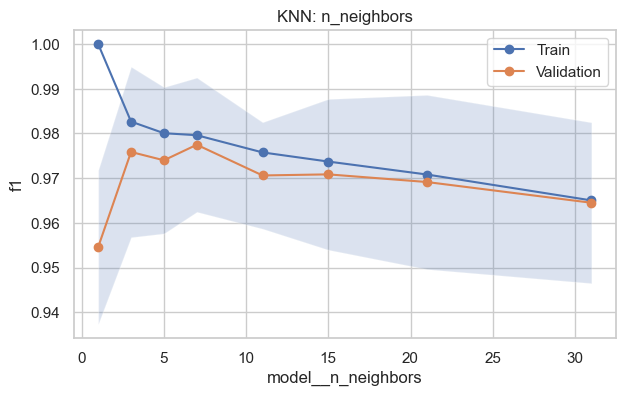

,model__n_neighbors,train_mean,validation_mean,validation_std
0,1,1.000000,0.954578,0.017206
1,3,0.982656,0.975860,0.019066
2,5,0.980060,0.973999,0.016362
3,7,0.979609,0.977478,0.015009
4,11,0.975761,0.970607,0.011911
5,15,0.973715,0.970851,0.016868
6,21,0.970819,0.969139,0.019486
7,31,0.965028,0.964503,0.017987


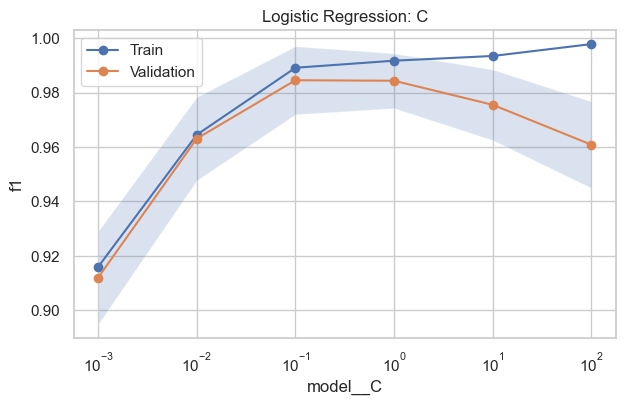

,model__C,train_mean,validation_mean,validation_std
0,0.001,0.915908,0.911956,0.017107
1,0.01,0.964473,0.963078,0.015322
2,0.1,0.989118,0.984525,0.012517
3,1,0.991712,0.984344,0.010069
4,10,0.993449,0.975494,0.012976
5,100,0.997818,0.960829,0.015928


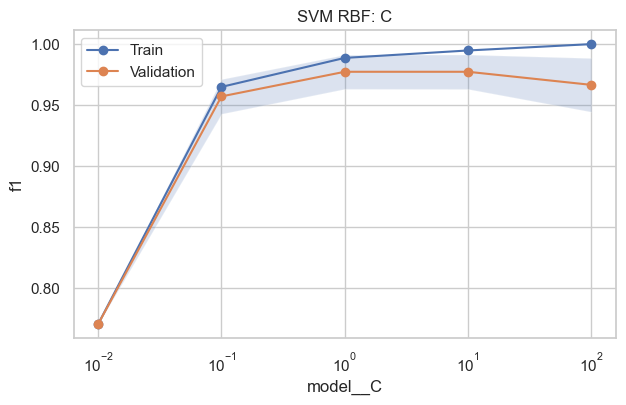

,model__C,train_mean,validation_mean,validation_std
0,0.01,0.770270,0.770270,0.000000
1,0.1,0.964873,0.957082,0.014202
2,1,0.988675,0.977292,0.014038
3,10,0.994769,0.977290,0.014150
4,100,1.000000,0.966547,0.022055


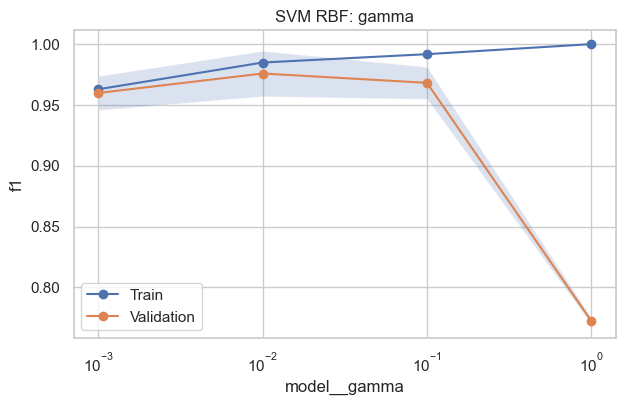

,model__gamma,train_mean,validation_mean,validation_std
0,0.001,0.962844,0.959798,0.013984
1,0.01,0.984842,0.975827,0.018604
2,0.1,0.991719,0.968157,0.013167
3,1,1.000000,0.772366,0.002567


In [12]:
knn_pipe = Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())])
knn_vc = plot_validation_curve(knn_pipe, "model__n_neighbors", [1,3,5,7,11,15,21,31], X_train_full, y_train_full, title="KNN: n_neighbors")
display(knn_vc)

log_vc = plot_validation_curve(base_model, "model__C", [0.001,0.01,0.1,1,10,100], X_train_full, y_train_full, logx=True, title="Logistic Regression: C")
display(log_vc)

svm_pipe = Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf"))])
svm_C_vc = plot_validation_curve(svm_pipe, "model__C", [0.01,0.1,1,10,100], X_train_full, y_train_full, logx=True, title="SVM RBF: C")
display(svm_C_vc)
svm_gamma_vc = plot_validation_curve(svm_pipe, "model__gamma", [0.001,0.01,0.1,1], X_train_full, y_train_full, logx=True, title="SVM RBF: gamma")
display(svm_gamma_vc)

### Analytical interpretation

The SVM results should be interpreted through boundary complexity. Very small `C` or very small `gamma` can underfit; very large values can create overly local boundaries. A good setting balances margin flexibility with validation stability.

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

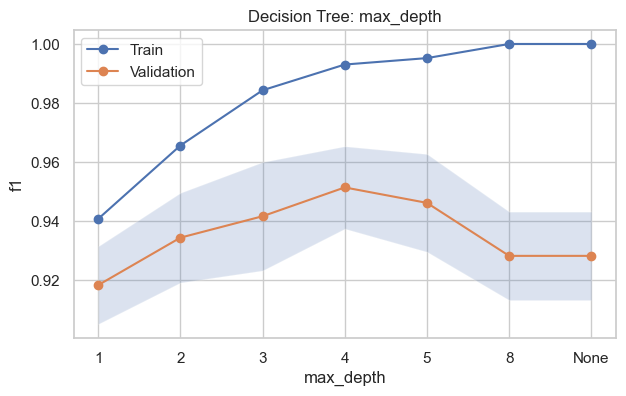

,max_depth,train_mean,validation_mean,validation_std
0,1,0.940703,0.918252,0.013162
1,2,0.965579,0.934341,0.015208
2,3,0.984302,0.941606,0.018376
3,4,0.993026,0.951374,0.013970
4,5,0.995209,0.946139,0.016576
5,8,1.000000,0.928176,0.014981
6,None,1.000000,0.928176,0.014981


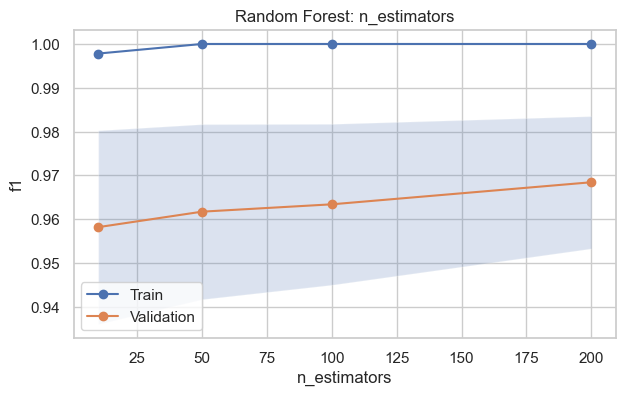

,n_estimators,train_mean,validation_mean,validation_std
0,10,0.99781,0.958196,0.022092
1,50,1.00000,0.961730,0.019980
2,100,1.00000,0.963408,0.018366
3,200,1.00000,0.968444,0.015105


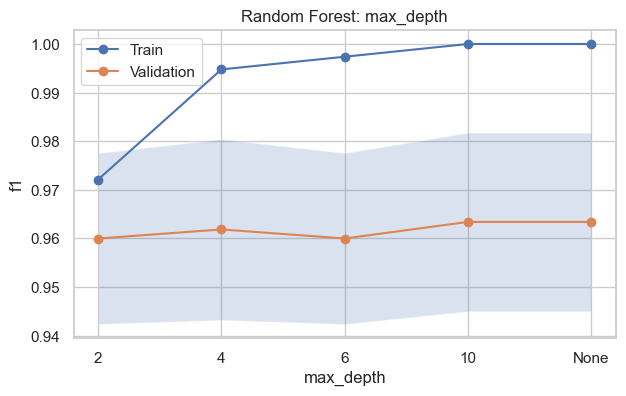

,max_depth,train_mean,validation_mean,validation_std
0,2,0.972121,0.959991,0.017578
1,4,0.994767,0.961851,0.018589
2,6,0.997378,0.959991,0.017578
3,10,1.000000,0.963408,0.018366
4,None,1.000000,0.963408,0.018366


In [13]:
tree_vc = plot_validation_curve(DecisionTreeClassifier(random_state=RANDOM_STATE), "max_depth", [1,2,3,4,5,8,None], X_train_full, y_train_full, title="Decision Tree: max_depth")
display(tree_vc)

rf_vc = plot_validation_curve(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), "n_estimators", [10,50,100,200], X_train_full, y_train_full, title="Random Forest: n_estimators")
display(rf_vc)
rf_depth_vc = plot_validation_curve(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), "max_depth", [2,4,6,10,None], X_train_full, y_train_full, title="Random Forest: max_depth")
display(rf_depth_vc)

### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Bias-variance discussion

Use the validation curves to identify high-bias regions, high-variance regions, and stable regions. Prefer a stable region over a single noisy peak.

## Manual hyperparameter reasoning

Based on the curves above, define a few candidate models. The chosen values should be justified by validation stability, simplicity, and computational cost.

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

In [14]:
candidate_models = {
    "LogReg C=1": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(C=1, max_iter=5000))]),
    "KNN k=7": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=7))]),
    "SVM RBF C=1": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", C=1, gamma="scale", probability=True))]),
    "Tree depth=3": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "RF depth=None": RandomForestClassifier(n_estimators=100, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1),
}
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
rows=[]
for name, model in candidate_models.items():
    start=time.time()
    scores = cross_val_score(model, X_train_full, y_train_full, cv=cv, scoring="f1", n_jobs=-1)
    runtime=time.time()-start
    rows.append({"Model": name, "mean_F1": scores.mean(), "std_F1": scores.std(), "runtime_sec": runtime})
selection_df = pd.DataFrame(rows).sort_values("mean_F1", ascending=False)
display(selection_df)

,Model,mean_F1,std_F1,runtime_sec
0,LogReg C=1,0.978525,0.007680,0.165382
2,SVM RBF C=1,0.976673,0.008154,0.208307
1,KNN k=7,0.973398,0.013254,0.139187
4,RF depth=None,0.970223,0.012871,2.437956
3,Tree depth=3,0.936845,0.018179,0.119941


### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Optional: GridSearchCV as reference only

Grid search is a useful tool, but it is not a substitute for understanding. Search spaces should be designed after inspecting model behavior.

GridSearchCV is included only as a reference. The search space should be informed by earlier validation-curve reasoning rather than treated as a substitute for understanding.

In [15]:
# Optional reference only
from sklearn.model_selection import GridSearchCV
param_grid = {"model__C": [0.1, 1, 10]}
grid = GridSearchCV(Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000))]), param_grid, cv=5, scoring="f1")
grid.fit(X_train_full, y_train_full)
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best params: {'model__C': 0.1}
Best CV F1: 0.9845246868091377


### Analytical interpretation

The automated search should be compared with the manual reasoning from validation curves. If it selects an extreme value or a narrow peak, that result should be questioned rather than accepted blindly.

## Final test evaluation

Evaluate the selected model once on the held-out test set.

The classification report and confusion matrix break performance into error types. This is more informative than accuracy alone, especially when classes are imbalanced or specific mistakes are more costly.

Selected model: LogReg C=1
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

ROC-AUC: 0.9953703703703703


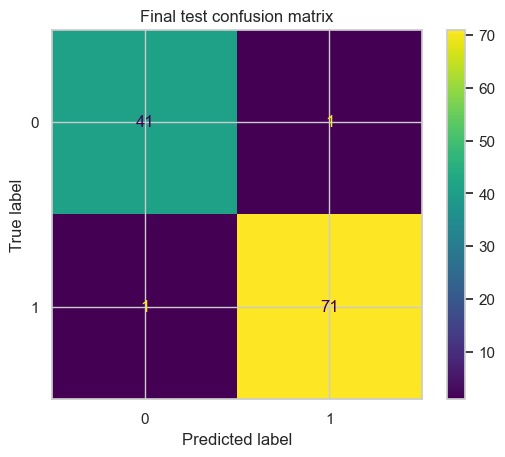

In [16]:
selected_name = selection_df.iloc[0]["Model"]
selected_model = candidate_models[selected_name]
selected_model.fit(X_train_full, y_train_full)
test_pred = selected_model.predict(X_test)
test_score = selected_model.predict_proba(X_test)[:,1] if hasattr(selected_model, "predict_proba") else None
print("Selected model:", selected_name)
print(classification_report(y_test, test_pred, zero_division=0))
if test_score is not None:
    print("ROC-AUC:", roc_auc_score(y_test, test_score))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title("Final test confusion matrix")
plt.show()

### Analytical interpretation

The confusion matrix and report identify which class or error type drives the score. For imbalanced data, recall and precision for the positive/minority class are more informative than accuracy alone.

## Additional analytical experiment: nested cross-validation as a stronger selection estimate

The notebook mainly uses validation curves and manual reasoning. Nested cross-validation is a stricter evaluation design when hyperparameters are selected inside each training fold and evaluated on an outer fold. It is more expensive but reduces optimistic bias in model-selection estimates.

In [17]:
from sklearn.model_selection import GridSearchCV

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

nested_pipe = Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf"))])
small_param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": [0.001, 0.01, 0.1]
}
inner_search = GridSearchCV(nested_pipe, small_param_grid, cv=inner_cv, scoring="f1")
nested_scores = cross_val_score(inner_search, X_train_full, y_train_full, cv=outer_cv, scoring="f1")

print("Nested CV F1 scores:", np.round(nested_scores, 4))
print("Nested CV mean ± std:", round(nested_scores.mean(), 4), "±", round(nested_scores.std(), 4))


Nested CV F1 scores: [0.9573 0.9912 0.9913 0.9828 0.9913]
Nested CV mean ± std: 0.9828 ± 0.0132


### How to interpret this added experiment
Compare the nested-CV mean with the earlier non-nested CV and final test score. If nested CV is slightly lower, that is normal because it accounts for hyperparameter selection uncertainty. This section is intentionally compact because nested CV is a validation-design concept, not a replacement for analytical hyperparameter curves.

## Interpretation

Compare final test performance with cross-validation estimates. Large disagreement may indicate high variance, data shift, or overly optimistic model selection.

## Limitations

- This is one dataset, so conclusions about algorithms are not universal.
- Cross-validation estimates still have uncertainty.
- Hyperparameter values were manually reasoned, not exhaustively optimized.
- Leakage demonstrations may show small numerical differences on clean datasets but remain conceptually important.

## What we learned

This project covered split instability, k-fold and stratified CV, repeated CV, leakage-safe pipelines, learning curves, validation curves, bias-variance reasoning, manual model selection, and final test evaluation.

## Possible extensions

Try nested cross-validation, Bayesian optimization, statistical model comparison, calibration, and multi-dataset benchmarking.